<a href="https://colab.research.google.com/github/Clover130/u8229609-EMSC2010-W10-P1/blob/main/EMSC2010_W10_P1_NB3_u8229609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-P1-NB3
In this notebook we'll use the Fourier transform to analyse the LR04 oxygen isotope record spanning the last 800 thousand years.

We'll also apply filtering to isolate different Milankovitch cycles within the record.

The data is in Excel file ```LR04.xlsx``` which is part of the GitHub repository. Remember to add/drag the file into your workspace so that it can be loaded into Colab.

First, load the packages we'll need.

In [1]:
import pandas as pd #for data import
import numpy as np #for numerical operations
import matplotlib.pyplot as plt #for plotting

Now define the functions:

*   ```freq_spectrum```: calculates the frequency spectrum for a signal.
*   ```lowpass_filter```: will remove frequencies higher than ```cutoff```.
*   ```highpass_filter```: will remove frequencies lower than ```cutoff```.
*   ```bandpass_filter```: will remove frequencies lower than ```cutoff[0]``` or higher than ```cutoff[1]```.



In [2]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

Read in the data and convert to ```numpy``` arrays.

In [3]:
file = 'LR04.xlsx' #datafile name
df = pd.read_excel(file) #read the data in as a dataframe
age = df['Age [ka]'].values #get the age values as a numpy array
d18O = df['d18O [per mil]'].values #get the d18O values as a numpy array

Plot the data. Note how we can used symbols in the labels based on LaTeX formatting.

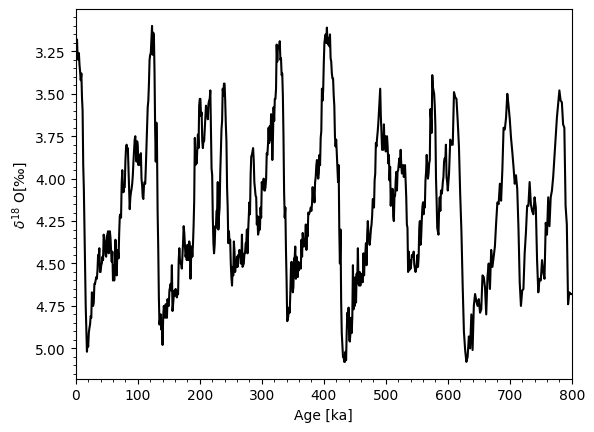

In [4]:
plt.plot(age,d18O,'k') #plot the d18O data
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

Calculate and plot the frequency spectrum.

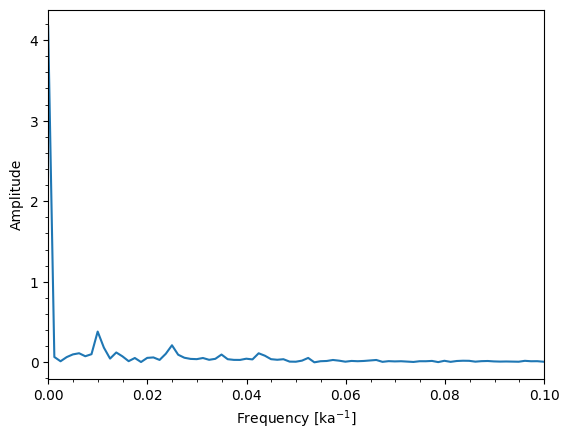

In [5]:
freqs, amps = freq_spectrum(age,d18O) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [ka$^{-1}$]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

- the straight line (tilt due to slight decrease over time) gets interpreted as a straight line that is infinitely long --> hence we remove it

The result is a bit disappointing. We don't see the Milankovitch cycles clearly even though the are obvious in the original record.

This is because the data contain a long-term trend, which expresses itself in the frequency spectrum as a large amplitude cycle with a frequency of zero.

If we detrend the data using a polynomial (remember back to the Keeling curve example), we can remove the effect of the long-term trend.

As a first step, we'll fit a straight-line (first-order polynomial) to the record using ```np.polyfit()```.

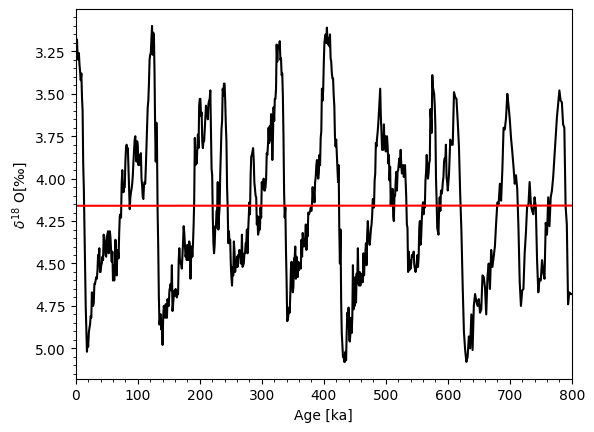

In [6]:
pp = np.polyfit(age,d18O,1) #fit a trendline to the data
plt.plot(age,d18O,'k') #plot the original data
plt.plot(age,np.polyval(pp,age),'r') #plot the trendline
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

The detrended data is simply the original data minus the fitted line. We call this ```detrend``` and calculate its frequency spectrum.

We can also use ```plt.gca().axvline``` to plot vertical lines at the frequencies corresponding to the Milankovitch cycles.

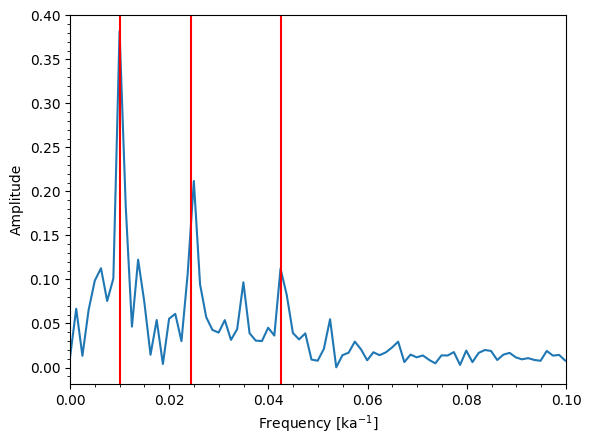

In [7]:
detrend = d18O-np.polyval(pp,age) #calculate the detrended data
freqs, amps = freq_spectrum(age,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [ka$^{-1}$]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

plt.gca().axvline(x=1/100,color='r') #mark eccentricity frequency
plt.gca().axvline(x=1/41,color='r') #mark obliquity frequency
plt.gca().axvline(x=1/23.5,color='r') #mark precession frequency

We can now see the clear expression of the Milankovitch cycles in the LR04 data.

Image we want to isolate certain frequency components of the signal to represent the contribution of the different Milankovitch cycles. For example, we can use ```lowpass``` to isolate the eccentricity component by removing the higher frequency components (obliquity and precession).

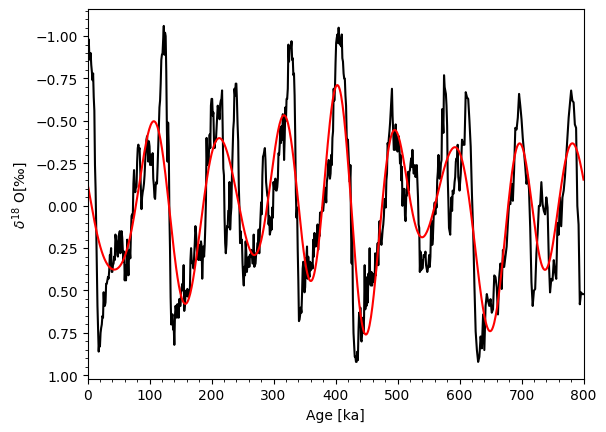

In [8]:
plt.plot(age,detrend,'k') #plot the detrended data
x, y = lowpass_filter(age,detrend,1/70) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

We can use ```highpass``` to isolate the precession component by removing the lower frequency components (eccentricity and obliquity).

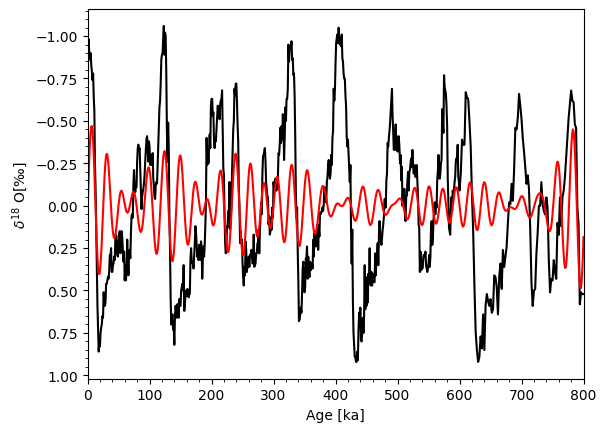

In [14]:
plt.plot(age,detrend,'k') #plot the detrended data
#x, y = highpass_filter(age,detrend,1/30) #obtain the filtered signal
x, y = bandpass_filter(age,detrend,[1/30,1/20]) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

We can use ```bandpass``` to isolate the obliquity component by removing both the higher (precession) and lower (eccentricity) frequency components.

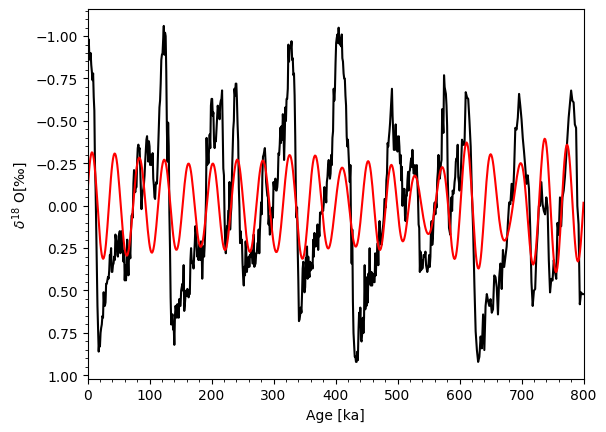

In [10]:
plt.plot(age,detrend,'k') #plot the detrended data
x, y = bandpass_filter(age,detrend,[1/50,1/30]) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks